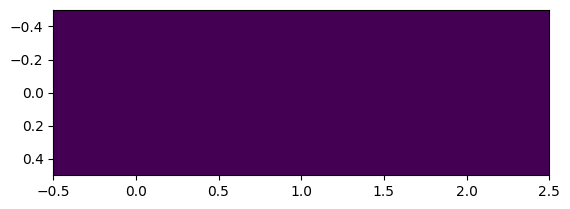

In [5]:
import cv2
import matplotlib.pyplot as plt
H = 100
W = 100
bridge = max(3, int(min(H, W) * 0.02))  # ~2% chiều ngắn ảnh
h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (bridge, 1))


plt.imshow(h_kernel)
plt.show()


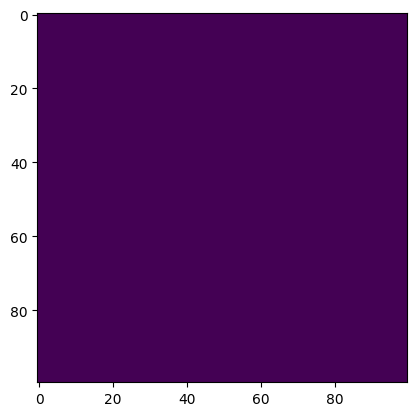

In [2]:
import numpy as np
H = 100
W = 100
union_mask = np.zeros((H, W), dtype=np.uint8)
union_mask = cv2.morphologyEx(union_mask, cv2.MORPH_CLOSE, h_kernel)

# Vẽ union_mask
plt.imshow(union_mask)
plt.show()



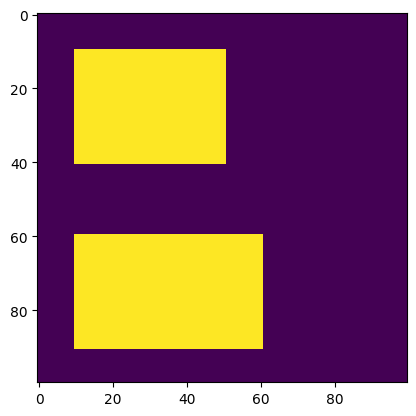

In [3]:
# Lỗi là do pts không phải là một mảng tọa độ điểm hợp lệ cho fillPoly.
# fillPoly yêu cầu pts phải là mảng 2 chiều (N, 2), mỗi hàng là một điểm (x, y).
# Ở đây, np.array((10, 10, 10, 10), dtype=np.int32) chỉ là mảng 1 chiều, không phải là danh sách các điểm (x, y).
# Để vẽ một đa giác (ví dụ hình chữ nhật), pts phải có dạng như sau:
# Đúng, bạn đã vẽ 2 hình chữ nhật, một ở trên (pts1) và một ở dưới (pts2).
# pts1: Hình chữ nhật từ (10,10) đến (50,50)
# Vẽ lại 2 hình chữ nhật: một ở phía trên, một ở phía dưới

# Hình chữ nhật phía trên: từ (10, 10) đến (50, 40)
pts_top = np.array([[10, 10], [10, 40], [50, 40], [50, 10]], dtype=np.int32)
# Hình chữ nhật phía dưới: từ (10, 60) đến (50, 90)
pts_bottom = np.array([[10, 60], [10, 90], [60, 90], [60, 60]], dtype=np.int32)

cv2.fillPoly(union_mask, [pts_top], 255)
cv2.fillPoly(union_mask, [pts_bottom], 255)
plt.imshow(union_mask)
plt.show()


In [4]:
union_mask = cv2.dilate(union_mask, kernel)
plt.imshow(union_mask)
plt.show()

NameError: name 'kernel' is not defined

[[[10  5]]

 [[11  5]]

 [[12  5]]

 ...

 [[58 95]]

 [[59 95]]

 [[60 95]]]


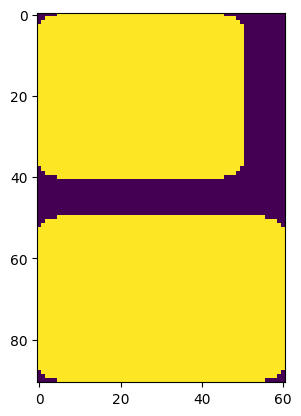

In [ ]:
non_zero = cv2.findNonZero(union_mask)
print(non_zero)

x,y,w,h = cv2.boundingRect(non_zero)
crop = union_mask[y:y+h, x:x+w].copy()

plt.imshow(crop)
plt.show()



In [ ]:
crop = union_mask[y:y+h, x:x+w].copy()
polygon_masks = []
polygon_masks.append((crop, [x, y, x + w, y + h]))

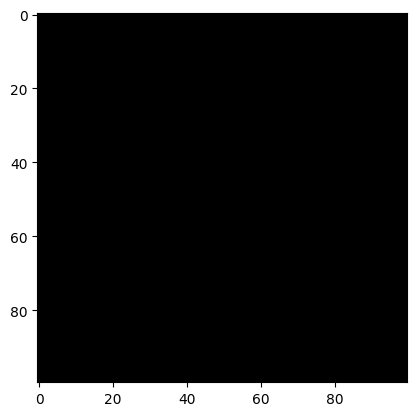

In [ ]:
from PIL import Image
import numpy as np
img_poly = np.array(Image.new("RGB", (W, H), (0, 0, 0)).convert("RGBA"))
plt.imshow(img_poly)

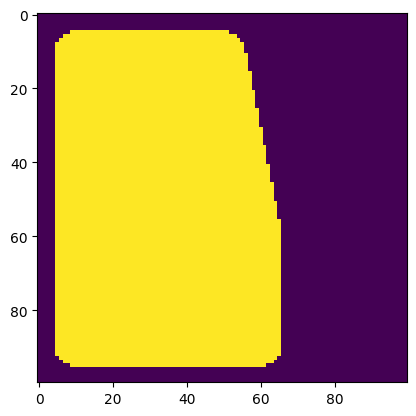

In [ ]:
# Nối 2 vùng bằng "cầu nối" ngắn nhất giữa 2 contour (không padding 4 hướng)
import numpy as np, cv2

contours, _ = cv2.findContours(union_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if len(contours) >= 2:
    pts = np.vstack([contours[0].reshape(-1,2), contours[1].reshape(-1,2)])
    hull = cv2.convexHull(pts)
    cv2.fillPoly(union_mask, [hull], 255)

# (Tùy chọn) đóng kín nhẹ để lấp khe hở nhỏ
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
union_mask = cv2.morphologyEx(union_mask, cv2.MORPH_CLOSE, se)

import matplotlib.pyplot as plt
plt.imshow(union_mask)
plt.show()
